# TDC Dataset Analysis

create a tdc environment (python 3.11) and install TDC for this to work

run this in terminal: conda activate tdc_py311

# Section 1: Single-Instance Predictions

In [1]:
from tdc.single_pred import ADME

caco2 = ADME(name='Caco2_Wang', path='/Users/elenipsaromati/tdc_data')
bioavail = ADME(name='Bioavailability_Ma', path='/Users/elenipsaromati/tdc_data')

df_caco2 = caco2.get_data()
df_bioavail = bioavail.get_data()

print(df_caco2.head())
print(df_bioavail.head())

Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!


                                             Drug_ID  \
0                                    (-)-epicatechin   
1  (2E,4Z,8Z)-N-isobutyldodeca-2,4,10-triene-8 -y...   
2                                            codeine   
3                                         creatinine   
4                                            danazol   

                                                Drug         Y  
0            Oc1cc(O)c2c(c1)OC(c1ccc(O)c(O)c1)C(O)C2 -6.220000  
1                   C/C=C\C#CCC/C=C\C=C\C(=O)NCC(C)C -3.860000  
2  COc1ccc2c3c1O[C@H]1[C@@H](O)C=C[C@H]4[C@@H](C2... -4.090000  
3                                     CN1CC(=O)NC1=N -5.935409  
4  C#C[C@]1(O)CC[C@H]2[C@@H]3CCC4=Cc5oncc5C[C@]4(... -4.840000  
       Drug_ID                                               Drug  Y
0  Dimercaprol                                           OCC(S)CS  0
1  Edrophonium                            CC[N+](C)(C)c1cccc(O)c1  0
2  Carbimazole                               CCOC(=O)n1ccn(C)c1=S 

In [2]:
from rdkit import Chem

def smiles_to_inchikey(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    return Chem.inchi.MolToInchiKey(mol)

df_caco2['inchikey'] = df_caco2['Drug'].apply(smiles_to_inchikey)
df_bioavail['inchikey'] = df_bioavail['Drug'].apply(smiles_to_inchikey)

common = set(df_caco2['inchikey']).intersection(set(df_bioavail['inchikey']))
print(f'Caco-2 size: {len(df_caco2)}')
print(f'Bioavailability size: {len(df_bioavail)}')
print(f'Overlap: {len(common)}')

Caco-2 size: 910
Bioavailability size: 640
Overlap: 108


## Checking overlap between ADME datasets

In [3]:
from tdc.single_pred import ADME
from rdkit import Chem
import pandas as pd

dataset_names = [
    'Caco2_Wang', 'PAMPA_NCATS', 'HIA_Hou', 'Pgp_Broccatelli',
    'Bioavailability_Ma', 'Lipophilicity_AstraZeneca', 'Solubility_AqSolDB',
    'HydrationFreeEnergy_FreeSolv', 'BBB_Martins', 'PPBR_AZ', 'VDss_Lombardo',
    'CYP2C19_Veith', 'CYP2D6_Veith', 'CYP3A4_Veith', 'CYP1A2_Veith',
    'CYP2C9_Veith', 'CYP2C9_Substrate_CarbonMangels',
    'CYP2D6_Substrate_CarbonMangels', 'CYP3A4_Substrate_CarbonMangels',
    'Half_Life_Obach', 'Clearance_Hepatocyte_AZ', 'Clearance_Microsome_AZ'
]

def smiles_to_inchikey(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    return Chem.inchi.MolToInchiKey(mol)

# load all datasets and compute inchikeys
datasets = {}
for name in dataset_names:
    data = ADME(name=name, path='/Users/elenipsaromati/tdc_data')
    df = data.get_data()
    df['inchikey'] = df['Drug'].apply(smiles_to_inchikey)
    datasets[name] = set(df['inchikey'].dropna())
    print(f'Loaded {name}: {len(datasets[name])} compounds')

# compute pairwise overlaps
results = []
names = list(datasets.keys())
for i in range(len(names)):
    for j in range(i+1, len(names)):
        n1, n2 = names[i], names[j]
        overlap = len(datasets[n1].intersection(datasets[n2]))
        results.append({'Dataset 1': n1, 'Dataset 2': n2, 'Overlap': overlap,
                        'Size 1': len(datasets[n1]), 'Size 2': len(datasets[n2])})

df_results = pd.DataFrame(results).sort_values('Overlap', ascending=False)
print(df_results.to_string(index=False))

Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!


Loaded Caco2_Wang: 898 compounds


Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!


Loaded PAMPA_NCATS: 2034 compounds
Loaded HIA_Hou: 578 compounds


Found local copy...
Loading...
Done!
Found local copy...
Loading...


...

Loaded CYP2D6_Substrate_CarbonMangels: 664 compounds
Loaded CYP3A4_Substrate_CarbonMangels: 667 compounds


Found local copy...
Loading...
Done!


Loaded Half_Life_Obach: 665 compounds


Found local copy...
Loading...
Done!


Loaded Clearance_Hepatocyte_AZ: 1020 compounds
Loaded Clearance_Microsome_AZ: 1102 compounds
                     Dataset 1                      Dataset 2  Overlap  Size 1  Size 2
                 CYP2C19_Veith                   CYP2D6_Veith    10196   12665   13130
                  CYP2D6_Veith                   CYP1A2_Veith    10123   13130   12578
                  CYP2D6_Veith                   CYP3A4_Veith     9932   13130   12327
                 CYP2C19_Veith                   CYP1A2_Veith     9804   12665   12578
                  CYP2D6_Veith                   CYP2C9_Veith     9750   13130   12092
                 CYP2C19_Veith                   CYP2C9_Veith     9704   12665   12092
                 CYP2C19_Veith                   CYP3A4_Veith     9659   12665   12327
                  CYP3A4_Veith                   CYP1A2_Veith     9534   12327   12578
                  CYP1A2_Veith                   CYP2C9_Veith     9406   12578   12092
                  CYP3A4_Veith       

In [5]:
top10 = df_results.head(10)
print(top10[['Dataset 1', 'Dataset 2', 'Overlap', 'Size 1', 'Size 2']].to_string(index=False))

    Dataset 1    Dataset 2  Overlap  Size 1  Size 2
CYP2C19_Veith CYP2D6_Veith    10196   12665   13130
 CYP2D6_Veith CYP1A2_Veith    10123   13130   12578
 CYP2D6_Veith CYP3A4_Veith     9932   13130   12327
CYP2C19_Veith CYP1A2_Veith     9804   12665   12578
 CYP2D6_Veith CYP2C9_Veith     9750   13130   12092
CYP2C19_Veith CYP2C9_Veith     9704   12665   12092
CYP2C19_Veith CYP3A4_Veith     9659   12665   12327
 CYP3A4_Veith CYP1A2_Veith     9534   12327   12578
 CYP1A2_Veith CYP2C9_Veith     9406   12578   12092
 CYP3A4_Veith CYP2C9_Veith     9265   12327   12092


## Toxicity overlap

In [6]:
from tdc.single_pred import Tox
from rdkit import Chem
import pandas as pd

tox_names = ['LD50_Zhu', 'hERG', 'hERG_Karim', 'AMES', 'DILI',
             'Skin_Reaction', 'Carcinogens_Lagunin', 'ClinTox']

def smiles_to_inchikey(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    return Chem.inchi.MolToInchiKey(mol)

datasets = {}
for name in tox_names:
    try:
        data = Tox(name=name, path='/Users/elenipsaromati/tdc_data')
        df = data.get_data()
        df['inchikey'] = df['Drug'].apply(smiles_to_inchikey)
        datasets[name] = set(df['inchikey'].dropna())
        print(f'Loaded {name}: {len(datasets[name])}')
    except Exception as e:
        print(f'Failed {name}: {e}')

results = []
names = list(datasets.keys())
for i in range(len(names)):
    for j in range(i+1, len(names)):
        n1, n2 = names[i], names[j]
        overlap = len(datasets[n1].intersection(datasets[n2]))
        results.append({'Dataset 1': n1, 'Dataset 2': n2, 'Overlap': overlap,
                        'Size 1': len(datasets[n1]), 'Size 2': len(datasets[n2])})

df_tox = pd.DataFrame(results).sort_values('Overlap', ascending=False)
print('\nTop 10 Tox overlapping pairs:')
print(df_tox.head(10).to_string(index=False))

Downloading...
100%|██████████| 707k/707k [00:00<00:00, 1.46MiB/s]
Loading...
Done!
Downloading...


Loaded LD50_Zhu: 7342


100%|██████████| 50.2k/50.2k [00:00<00:00, 582kiB/s]
Loading...
Done!
[15:56:49] WARNING: not removing hydrogen atom without neighbors
[15:56:49] WARNING: not removing hydrogen atom without neighbors
Downloading...


Loaded hERG: 644


100%|██████████| 885k/885k [00:00<00:00, 1.84MiB/s]
Loading...
Done!
Downloading...


...

Loaded Skin_Reaction: 404


100%|██████████| 20.2k/20.2k [00:00<00:00, 9.69MiB/s]
Loading...
Done!
Downloading...


Loaded Carcinogens_Lagunin: 278


100%|██████████| 110k/110k [00:00<00:00, 532kiB/s] 
Loading...
Done!
[15:57:03] Invalid InChI prefix in generating InChI Key


Loaded ClinTox: 1455

Top 10 Tox overlapping pairs:
 Dataset 1     Dataset 2  Overlap  Size 1  Size 2
  LD50_Zhu          AMES     1424    7342    7248
      hERG    hERG_Karim      458     644   13267
  LD50_Zhu          DILI      188    7342     475
  LD50_Zhu Skin_Reaction      138    7342     404
      AMES          DILI      137    7248     475
  LD50_Zhu       ClinTox      135    7342    1455
      AMES Skin_Reaction      124    7248     404
      AMES       ClinTox      123    7248    1455
hERG_Karim       ClinTox      110   13267    1455
      hERG       ClinTox      100     644    1455


## HTS Overlap

In [8]:
from tdc.single_pred import HTS
from rdkit import Chem
import pandas as pd

hts_names = ['SARSCoV2_3CLPro_Diamond', 'SARSCoV2_Vitro_Touret', 'HIV']

def smiles_to_inchikey(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    return Chem.inchi.MolToInchiKey(mol)

hts_datasets = {}
for name in hts_names:
    try:
        data = HTS(name=name, path='/Users/elenipsaromati/tdc_data')
        df = data.get_data()
        df['inchikey'] = df['Drug'].apply(smiles_to_inchikey)
        hts_datasets[name] = set(df['inchikey'].dropna())
        print(f'Loaded {name}: {len(hts_datasets[name])}')
    except Exception as e:
        print(f'Failed {name}: {e}')

results = []
names = list(hts_datasets.keys())
for i in range(len(names)):
    for j in range(i+1, len(names)):
        n1, n2 = names[i], names[j]
        overlap = len(hts_datasets[n1].intersection(hts_datasets[n2]))
        results.append({'Dataset 1': n1, 'Dataset 2': n2, 'Overlap': overlap,
                        'Size 1': len(hts_datasets[n1]), 'Size 2': len(hts_datasets[n2])})

df_hts = pd.DataFrame(results).sort_values('Overlap', ascending=False)
print('\nHTS overlapping pairs:')
print(df_hts.to_string(index=False))

Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!


Loaded SARSCoV2_3CLPro_Diamond: 879


Found local copy...
Loading...
Done!


Loaded SARSCoV2_Vitro_Touret: 1480


[15:58:16] WARNING: not removing hydrogen atom without neighbors
[15:58:16] WARNING: not removing hydrogen atom without neighbors
[15:58:16] bond type above 3 (17) is treated as unspecified!
[15:58:16] bond type above 3 (17) is treated as unspecified!
[15:58:16] Invalid InChI prefix in generating InChI Key


Loaded HIV: 41125

HTS overlapping pairs:
              Dataset 1             Dataset 2  Overlap  Size 1  Size 2
  SARSCoV2_Vitro_Touret                   HIV      111    1480   41125
SARSCoV2_3CLPro_Diamond SARSCoV2_Vitro_Touret        6     879    1480
SARSCoV2_3CLPro_Diamond                   HIV        4     879   41125


## QM 

In [8]:
from tdc.single_pred import QM

for name in ['QM7', 'QM7b', 'QM8', 'QM9']:
    try:
        data = QM(name=name, path='/Users/elenipsaromati/tdc_data')
        df = data.get_data()
        print(f'{name} loaded. Columns: {df.columns.tolist()}')
        print(df.head(2))
    except Exception as e:
        print(f'Failed {name}: {e}')

Failed QM7: Please select a label name. You can use tdc.utils.retrieve_label_name_list('qm7') to retrieve all available label names.
Failed QM7b: Please select a label name. You can use tdc.utils.retrieve_label_name_list('qm7b') to retrieve all available label names.
Failed QM8: Please select a label name. You can use tdc.utils.retrieve_label_name_list('qm8') to retrieve all available label names.
Failed QM9: Please select a label name. You can use tdc.utils.retrieve_label_name_list('qm9') to retrieve all available label names.


In [9]:
from tdc.utils import retrieve_label_name_list

for name in ['qm7', 'qm7b', 'qm8', 'qm9']:
    print(f'{name}: {retrieve_label_name_list(name)}')

qm7: ['Y']
qm7b: ['AE_PBE0', 'P_PBE0', 'P_SCS', 'HOMO_GW', 'HOMO_PBE0', 'HOMO_ZINDO', 'LUMO_GW', 'LUMO_PBE0', 'LUMO_ZINDO', 'IP_ZINDO', 'EA_ZINDO', 'E1_ZINDO', 'EMAX_ZINDO', 'IMAX_ZINDO']
qm8: ['E1-CC2', 'E2-CC2', 'f1-CC2', 'f2-CC2', 'E1-PBE0', 'E2-PBE0', 'f1-PBE0', 'f2-PBE0', 'E1-PBE0', 'E2-PBE0', 'f1-PBE0', 'f2-PBE0', 'E1-CAM', 'E2-CAM', 'f1-CAM']
qm9: ['A', 'B', 'C', 'mu', 'alpha', 'homo', 'lumo', 'gap', 'r2', 'zpve', 'U0', 'U', 'H', 'G', 'Cv']


QM datasets have multiple labels per molecule but the molecules themselves are the same within each dataset. So the overlap analysis only needs to load each dataset once with any label.

In [10]:
from tdc.single_pred import QM
from rdkit import Chem
import pandas as pd

qm_label_map = {
    'QM7': 'Y',
    'QM7b': 'AE_PBE0',
    'QM8': 'E1-CC2',
    'QM9': 'mu'
}

def smiles_to_inchikey(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    return Chem.inchi.MolToInchiKey(mol)

qm_datasets = {}
for name, label in qm_label_map.items():
    try:
        data = QM(name=name, label_name=label, path='/Users/elenipsaromati/tdc_data')
        df = data.get_data()
        print(f'{name} columns: {df.columns.tolist()}')
        col = 'Drug' if 'Drug' in df.columns else df.columns[0]
        df['inchikey'] = df[col].apply(smiles_to_inchikey)
        qm_datasets[name] = set(df['inchikey'].dropna())
        print(f'Loaded {name}: {len(qm_datasets[name])}')
    except Exception as e:
        print(f'Failed {name}: {e}')

results = []
names = list(qm_datasets.keys())
for i in range(len(names)):
    for j in range(i+1, len(names)):
        n1, n2 = names[i], names[j]
        overlap = len(qm_datasets[n1].intersection(qm_datasets[n2]))
        results.append({'Dataset 1': n1, 'Dataset 2': n2, 'Overlap': overlap,
                        'Size 1': len(qm_datasets[n1]), 'Size 2': len(qm_datasets[n2])})

if results:
    df_qm = pd.DataFrame(results).sort_values('Overlap', ascending=False)
    print('\nQM overlapping pairs:')
    print(df_qm.to_string(index=False))
else:
    print('No pairs to compare.')

Downloading...
100%|██████████| 3.30M/3.30M [00:00<00:00, 3.86MiB/s]
Loading...
Done!
Downloading...


QM7 columns: ['Drug_ID', 'Drug', 'Y']
Failed QM7: No registered converter was able to produce a C++ rvalue of type std::__1::basic_string<wchar_t, std::__1::char_traits<wchar_t>, std::__1::allocator<wchar_t>> from this Python object of type tuple


100%|██████████| 4.07M/4.07M [00:00<00:00, 5.31MiB/s]
Loading...
Done!
Downloading...


QM7b columns: ['Drug_ID', 'Drug', 'Y']
Failed QM7b: No registered converter was able to produce a C++ rvalue of type std::__1::basic_string<wchar_t, std::__1::char_traits<wchar_t>, std::__1::allocator<wchar_t>> from this Python object of type tuple


100%|██████████| 12.9M/12.9M [00:01<00:00, 8.36MiB/s]
Loading...
Done!
Downloading...


QM8 columns: ['Drug_ID', 'Drug', 'Y']
Failed QM8: No registered converter was able to produce a C++ rvalue of type std::__1::basic_string<wchar_t, std::__1::char_traits<wchar_t>, std::__1::allocator<wchar_t>> from this Python object of type tuple


100%|██████████| 85.8M/85.8M [00:08<00:00, 9.75MiB/s]
Loading...
Done!


QM9 columns: ['Drug_ID', 'Drug', 'Y']
Failed QM9: No registered converter was able to produce a C++ rvalue of type std::__1::basic_string<wchar_t, std::__1::char_traits<wchar_t>, std::__1::allocator<wchar_t>> from this Python object of type tuple
No pairs to compare.


## Yields 

# do NOT run this bc it WILL CRASH

In [ ]:
from tdc.single_pred import Yields
from rdkit import Chem
import pandas as pd

yields_names = ['Buchwald-Hartwig', 'USPTO_Yields']

def smiles_to_inchikey(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    return Chem.inchi.MolToInchiKey(mol)

yields_datasets = {}
for name in yields_names:
    try:
        data = Yields(name=name, path='/Users/elenipsaromati/tdc_data')
        df = data.get_data()
        print(f'{name} columns: {df.columns.tolist()}')
        col = 'Drug' if 'Drug' in df.columns else df.columns[0]
        df['inchikey'] = df[col].apply(smiles_to_inchikey)
        yields_datasets[name] = set(df['inchikey'].dropna())
        print(f'Loaded {name}: {len(yields_datasets[name])}')
    except Exception as e:
        print(f'Failed {name}: {e}')

results = []
names = list(yields_datasets.keys())
for i in range(len(names)):
    for j in range(i+1, len(names)):
        n1, n2 = names[i], names[j]
        overlap = len(yields_datasets[n1].intersection(yields_datasets[n2]))
        results.append({'Dataset 1': n1, 'Dataset 2': n2, 'Overlap': overlap,
                        'Size 1': len(yields_datasets[n1]), 'Size 2': len(yields_datasets[n2])})

df_yields = pd.DataFrame(results).sort_values('Overlap', ascending=False)
print('\nYields overlapping pairs:')
print(df_yields.to_string(index=False))

Downloading...
100%|██████████| 1.10M/1.10M [00:00<00:00, 1.73MiB/s]
Loading...
Done!
[16:00:54] SMILES Parse Error: syntax error while parsing: reactions_1
[16:00:54] SMILES Parse Error: Failed parsing SMILES 'reactions_1' for input: 'reactions_1'
[16:00:54] SMILES Parse Error: syntax error while parsing: reactions_2
[16:00:54] SMILES Parse Error: Failed parsing SMILES 'reactions_2' for input: 'reactions_2'
[16:00:54] SMILES Parse Error: syntax error while parsing: reactions_3
[16:00:54] SMILES Parse Error: Failed parsing SMILES 'reactions_3' for input: 'reactions_3'
[16:00:54] SMILES Parse Error: syntax error while parsing: reactions_4
[16:00:54] SMILES Parse Error: Failed parsing SMILES 'reactions_4' for input: 'reactions_4'
[16:00:54] SMILES Parse Error: syntax error while parsing: reactions_5
[16:00:54] SMILES Parse Error: Failed parsing SMILES 'reactions_5' for input: 'reactions_5'
[16:00:54] SMILES Parse Error: syntax error while parsing: reactions_6
[16:00:54] SMILES Parse Erro

Buchwald-Hartwig columns: ['Reaction_ID', 'Reaction', 'Y']


[16:00:54] SMILES Parse Error: Failed parsing SMILES 'reactions_715' for input: 'reactions_715'
[16:00:54] SMILES Parse Error: syntax error while parsing: reactions_716
[16:00:54] SMILES Parse Error: Failed parsing SMILES 'reactions_716' for input: 'reactions_716'
[16:00:54] SMILES Parse Error: syntax error while parsing: reactions_717
[16:00:54] SMILES Parse Error: Failed parsing SMILES 'reactions_717' for input: 'reactions_717'
[16:00:54] SMILES Parse Error: syntax error while parsing: reactions_718
[16:00:54] SMILES Parse Error: Failed parsing SMILES 'reactions_718' for input: 'reactions_718'
[16:00:54] SMILES Parse Error: syntax error while parsing: reactions_719
[16:00:54] SMILES Parse Error: Failed parsing SMILES 'reactions_719' for input: 'reactions_719'
[16:00:54] SMILES Parse Error: syntax error while parsing: reactions_720
[16:00:54] SMILES Parse Error: Failed parsing SMILES 'reactions_720' for input: 'reactions_720'
[16:00:54] SMILES Parse Error: syntax error while parsing: 

Loaded Buchwald-Hartwig: 0


100%|██████████| 432M/432M [01:54<00:00, 3.77MiB/s]  
Loading...


## Epitope

In [5]:
from tdc.single_pred import Epitope
import pandas as pd

epitope_names = ['IEDB_Jespersen', 'PDB_Jespersen']

epitope_datasets = {}
for name in epitope_names:
    try:
        data = Epitope(name=name, path='/Users/elenipsaromati/tdc_data')
        df = data.get_data()
        print(f'{name} columns: {df.columns.tolist()}')
        col = df.columns[0]
        epitope_datasets[name] = set(df[col].dropna())
        print(f'Loaded {name}: {len(epitope_datasets[name])}')
    except Exception as e:
        print(f'Failed {name}: {e}')

results = []
names = list(epitope_datasets.keys())
for i in range(len(names)):
    for j in range(i+1, len(names)):
        n1, n2 = names[i], names[j]
        overlap = len(epitope_datasets[n1].intersection(epitope_datasets[n2]))
        results.append({'Dataset 1': n1, 'Dataset 2': n2, 'Overlap': overlap,
                        'Size 1': len(epitope_datasets[n1]), 'Size 2': len(epitope_datasets[n2])})

df_epitope = pd.DataFrame(results).sort_values('Overlap', ascending=False)
print('\nEpitope overlapping pairs:')
print(df_epitope.to_string(index=False))

Downloading...
100%|██████████| 2.18M/2.18M [00:00<00:00, 3.01MiB/s]
Loading...
Done!
Downloading...


IEDB_Jespersen columns: ['Antigen_ID', 'Antigen', 'Y']
Loaded IEDB_Jespersen: 3159


100%|██████████| 135k/135k [00:00<00:00, 792kiB/s] 
Loading...
Done!


PDB_Jespersen columns: ['Antigen_ID', 'Antigen', 'Y']
Loaded PDB_Jespersen: 447

Epitope overlapping pairs:
     Dataset 1     Dataset 2  Overlap  Size 1  Size 2
IEDB_Jespersen PDB_Jespersen      447    3159     447


## Develop

In [6]:
from tdc.single_pred import Develop
import pandas as pd

develop_names = ['TAP', 'SAbDab_Chen']

develop_datasets = {}
for name in develop_names:
    try:
        data = Develop(name=name, path='/Users/elenipsaromati/tdc_data')
        df = data.get_data()
        print(f'{name} columns: {df.columns.tolist()}')
        col = df.columns[0]
        develop_datasets[name] = set(df[col].dropna())
        print(f'Loaded {name}: {len(develop_datasets[name])}')
    except Exception as e:
        print(f'Failed {name}: {e}')

results = []
names = list(develop_datasets.keys())
for i in range(len(names)):
    for j in range(i+1, len(names)):
        n1, n2 = names[i], names[j]
        overlap = len(develop_datasets[n1].intersection(develop_datasets[n2]))
        results.append({'Dataset 1': n1, 'Dataset 2': n2, 'Overlap': overlap,
                        'Size 1': len(develop_datasets[n1]), 'Size 2': len(develop_datasets[n2])})

df_develop = pd.DataFrame(results).sort_values('Overlap', ascending=False)
print('\nDevelop overlapping pairs:')
print(df_develop.to_string(index=False))

Downloading...


Failed TAP: Please select a label name. You can use tdc.utils.retrieve_label_name_list('tap') to retrieve all available label names.


100%|██████████| 601k/601k [00:00<00:00, 1.29MiB/s] 
Loading...
Done!


SAbDab_Chen columns: ['Antibody_ID', 'Antibody', 'Y']
Loaded SAbDab_Chen: 2409


KeyError: 'Overlap'

## CRISPROutcome

In [7]:
from tdc.single_pred import CRISPROutcome
import pandas as pd

crispr_names = ['Leenay']

crispr_datasets = {}
for name in crispr_names:
    try:
        data = CRISPROutcome(name=name, path='/Users/elenipsaromati/tdc_data')
        df = data.get_data()
        print(f'{name} columns: {df.columns.tolist()}')
        col = df.columns[0]
        crispr_datasets[name] = set(df[col].dropna())
        print(f'Loaded {name}: {len(crispr_datasets[name])}')
    except Exception as e:
        print(f'Failed {name}: {e}')

print(f'\nCRISPR only has one dataset so no pairwise overlap to compute.')

Failed Leenay: Please select a label name. You can use tdc.utils.retrieve_label_name_list('leenay') to retrieve all available label names.

CRISPR only has one dataset so no pairwise overlap to compute.


## Summary

In [13]:
from tdc.single_pred import ADME, Tox
from rdkit import Chem
import pandas as pd

def smiles_to_inchikey(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    return Chem.inchi.MolToInchiKey(mol)

adme_names = [
    'Caco2_Wang', 'PAMPA_NCATS', 'HIA_Hou', 'Pgp_Broccatelli',
    'Bioavailability_Ma', 'Lipophilicity_AstraZeneca', 'Solubility_AqSolDB',
    'HydrationFreeEnergy_FreeSolv', 'BBB_Martins', 'PPBR_AZ', 'VDss_Lombardo',
    'CYP2C19_Veith', 'CYP2D6_Veith', 'CYP3A4_Veith', 'CYP1A2_Veith',
    'CYP2C9_Veith', 'CYP2C9_Substrate_CarbonMangels',
    'CYP2D6_Substrate_CarbonMangels', 'CYP3A4_Substrate_CarbonMangels',
    'Half_Life_Obach', 'Clearance_Hepatocyte_AZ', 'Clearance_Microsome_AZ'
]

tox_names = ['LD50_Zhu', 'hERG', 'hERG_Karim', 'AMES', 'DILI',
             'Skin_Reaction', 'Carcinogens_Lagunin', 'ClinTox']

adme_datasets = {}
for name in adme_names:
    try:
        data = ADME(name=name, path='/Users/elenipsaromati/tdc_data')
        df = data.get_data()
        df['inchikey'] = df['Drug'].apply(smiles_to_inchikey)
        adme_datasets[name] = set(df['inchikey'].dropna())
        print(f'Loaded {name}: {len(adme_datasets[name])}')
    except Exception as e:
        print(f'Failed {name}: {e}')

tox_datasets = {}
for name in tox_names:
    try:
        data = Tox(name=name, path='/Users/elenipsaromati/tdc_data')
        df = data.get_data()
        df['inchikey'] = df['Drug'].apply(smiles_to_inchikey)
        tox_datasets[name] = set(df['inchikey'].dropna())
        print(f'Loaded {name}: {len(tox_datasets[name])}')
    except Exception as e:
        print(f'Failed {name}: {e}')

results_cross = []
for n1 in adme_names:
    for n2 in tox_names:
        if n1 in adme_datasets and n2 in tox_datasets:
            overlap = len(adme_datasets[n1].intersection(tox_datasets[n2]))
            results_cross.append({
                'ADME Dataset': n1,
                'ADME Size': len(adme_datasets[n1]),
                'Tox Dataset': n2,
                'Tox Size': len(tox_datasets[n2]),
                'Overlap': overlap,
                'Overlap % of ADME': round(100 * overlap / len(adme_datasets[n1]), 1),
                'Overlap % of Tox': round(100 * overlap / len(tox_datasets[n2]), 1)
            })

df_cross = pd.DataFrame(results_cross).sort_values('Overlap', ascending=False)
print('\nTop 5 ADME vs Tox overlapping pairs:')
print(df_cross.head(5).to_string(index=False))

Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!


Loaded Caco2_Wang: 898


Found local copy...
Loading...
Done!


Loaded PAMPA_NCATS: 2034
Loaded HIA_Hou: 578


Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!


...

Loaded AMES: 7248
Loaded DILI: 475


Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!


Loaded Skin_Reaction: 404
Loaded Carcinogens_Lagunin: 278


[16:33:26] Invalid InChI prefix in generating InChI Key


Loaded ClinTox: 1455

Top 5 ADME vs Tox overlapping pairs:
             ADME Dataset  ADME Size Tox Dataset  Tox Size  Overlap  Overlap % of ADME  Overlap % of Tox
       Solubility_AqSolDB       9982    LD50_Zhu      7342     2085               20.9              28.4
       Solubility_AqSolDB       9982        AMES      7248     1632               16.3              22.5
Lipophilicity_AstraZeneca       4200  hERG_Karim     13267      650               15.5               4.9
                  PPBR_AZ       1614  hERG_Karim     13267      367               22.7               2.8
              BBB_Martins       1971    LD50_Zhu      7342      342               17.4               4.7


In [15]:
print('\nADME vs ADME:')
print(df_adme_self[['Dataset 1', 'Dataset 2', 'Overlap']].sort_values('Overlap', ascending=False).to_string(index=False))

print('\nTox vs Tox:')
print(df_tox_self[['Dataset 1', 'Dataset 2', 'Overlap']].sort_values('Overlap', ascending=False).to_string(index=False))

print('\nADME vs Tox:')
print(df_cross[['ADME Dataset', 'Tox Dataset', 'Overlap']].sort_values('Overlap', ascending=False).to_string(index=False))


ADME vs ADME:
                     Dataset 1                      Dataset 2  Overlap
                 CYP2C19_Veith                   CYP2D6_Veith    10196
                  CYP2D6_Veith                   CYP1A2_Veith    10123
                  CYP2D6_Veith                   CYP3A4_Veith     9932
                 CYP2C19_Veith                   CYP1A2_Veith     9804
                  CYP2D6_Veith                   CYP2C9_Veith     9750
                 CYP2C19_Veith                   CYP2C9_Veith     9704
                 CYP2C19_Veith                   CYP3A4_Veith     9659
                  CYP3A4_Veith                   CYP1A2_Veith     9534
                  CYP1A2_Veith                   CYP2C9_Veith     9406
                  CYP3A4_Veith                   CYP2C9_Veith     9265
     Lipophilicity_AstraZeneca                        PPBR_AZ     1008
     Lipophilicity_AstraZeneca         Clearance_Microsome_AZ      886
     Lipophilicity_AstraZeneca        Clearance_Hepatocyte_AZ 

In [16]:
cyp_names = ['CYP2C19_Veith', 'CYP2D6_Veith', 'CYP3A4_Veith', 
             'CYP1A2_Veith', 'CYP2C9_Veith']

for i in range(len(cyp_names)):
    for j in range(i+1, len(cyp_names)):
        n1, n2 = cyp_names[i], cyp_names[j]
        overlap = len(adme_datasets[n1].intersection(adme_datasets[n2]))
        print(f'{n1} vs {n2}: {overlap}')

CYP2C19_Veith vs CYP2D6_Veith: 10196
CYP2C19_Veith vs CYP3A4_Veith: 9659
CYP2C19_Veith vs CYP1A2_Veith: 9804
CYP2C19_Veith vs CYP2C9_Veith: 9704
CYP2D6_Veith vs CYP3A4_Veith: 9932
CYP2D6_Veith vs CYP1A2_Veith: 10123
CYP2D6_Veith vs CYP2C9_Veith: 9750
CYP3A4_Veith vs CYP1A2_Veith: 9534
CYP3A4_Veith vs CYP2C9_Veith: 9265
CYP1A2_Veith vs CYP2C9_Veith: 9406


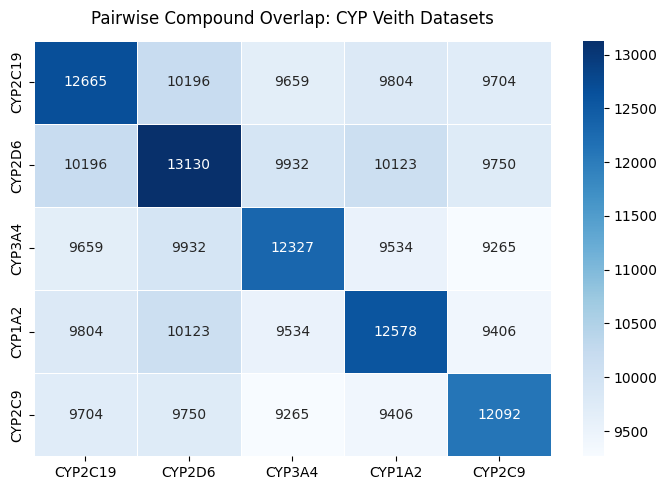

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cyp_names = ['CYP2C19_Veith', 'CYP2D6_Veith', 'CYP3A4_Veith', 
             'CYP1A2_Veith', 'CYP2C9_Veith']

short_names = ['CYP2C19', 'CYP2D6', 'CYP3A4', 'CYP1A2', 'CYP2C9']

n = len(cyp_names)
matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        if i == j:
            matrix[i][j] = len(adme_datasets[cyp_names[i]])
        else:
            matrix[i][j] = len(adme_datasets[cyp_names[i]].intersection(adme_datasets[cyp_names[j]]))

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(matrix, annot=True, fmt='.0f', cmap='Blues',
            xticklabels=short_names, yticklabels=short_names,
            ax=ax, linewidths=0.5)

ax.set_title('Pairwise Compound Overlap: CYP Veith Datasets', pad=12)
plt.tight_layout()
plt.savefig('cyp_overlap_heatmap.png', dpi=150)
plt.show()

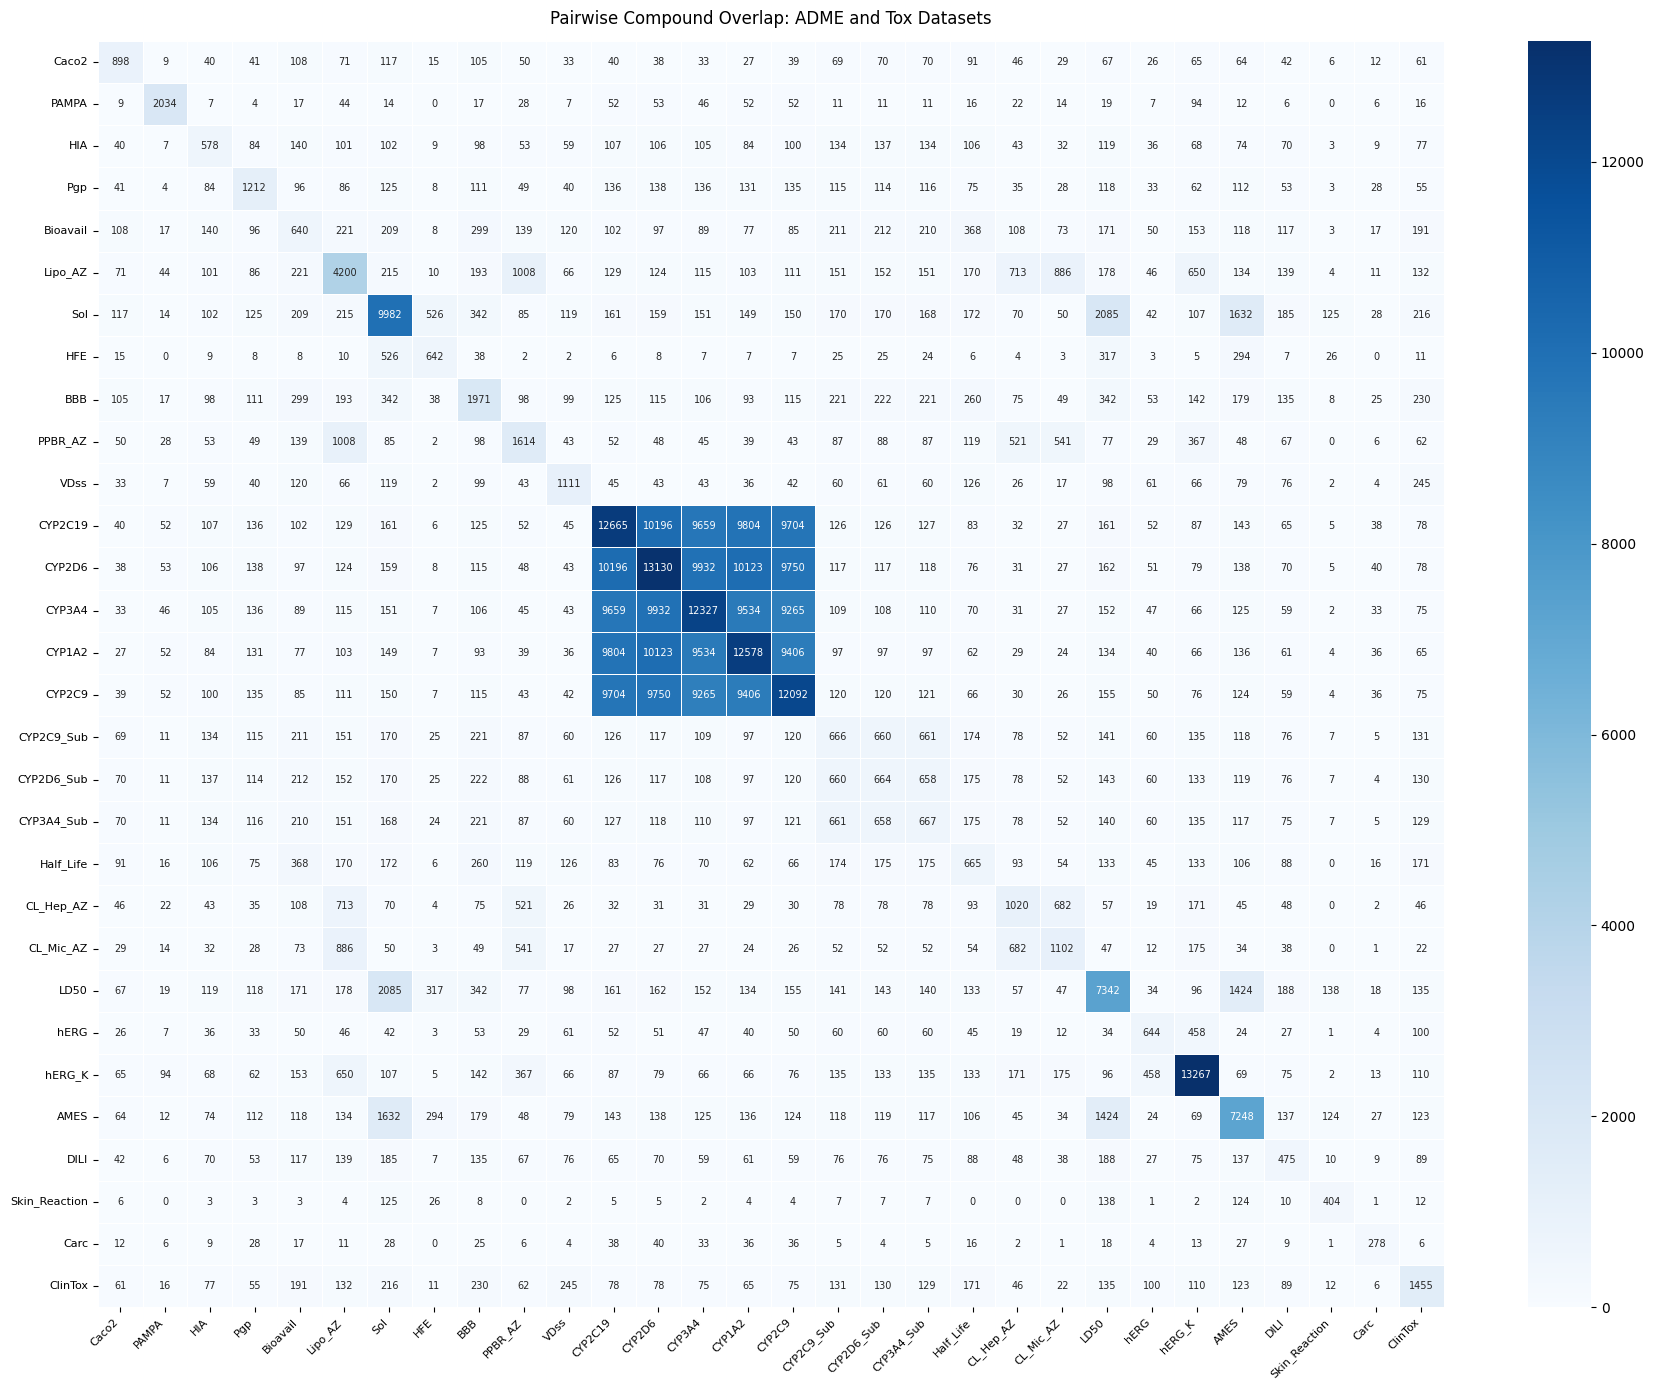

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

all_names = list(adme_datasets.keys()) + list(tox_datasets.keys())
all_datasets = {**adme_datasets, **tox_datasets}

short_names = [n.replace('_Veith', '').replace('_Broccatelli', '')
                .replace('_AstraZeneca', '_AZ').replace('_CarbonMangels', '')
                .replace('_Substrate', '_Sub').replace('_Hou', '')
                .replace('_Wang', '').replace('_Martins', '')
                .replace('_Lombardo', '').replace('_Obach', '')
                .replace('_Ma', '').replace('_AqSolDB', '')
                .replace('_FreeSolv', '').replace('_NCATS', '')
                .replace('_Zhu', '').replace('_Karim', '_K')
                .replace('_Lagunin', '').replace('HydrationFreeEnergy', 'HFE')
                .replace('Clearance_Hepatocyte', 'CL_Hep')
                .replace('Clearance_Microsome', 'CL_Mic')
                .replace('Bioavailability', 'Bioavail')
                .replace('Lipophilicity', 'Lipo')
                .replace('Solubility', 'Sol')
                .replace('Carcinogens', 'Carc')
                for n in all_names]

n = len(all_names)
matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        if i == j:
            matrix[i][j] = len(all_datasets[all_names[i]])
        else:
            matrix[i][j] = len(all_datasets[all_names[i]].intersection(all_datasets[all_names[j]]))

fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(matrix, annot=True, fmt='.0f', cmap='Blues',
            xticklabels=short_names, yticklabels=short_names,
            ax=ax, linewidths=0.5, annot_kws={'size': 7})

ax.set_title('Pairwise Compound Overlap: ADME and Tox Datasets', pad=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('adme_tox_overlap_heatmap.png', dpi=150)
plt.show()

Top 10 datasets by size:
hERG_Karim: 13267
CYP2D6_Veith: 13130
CYP2C19_Veith: 12665
CYP1A2_Veith: 12578
CYP3A4_Veith: 12327
CYP2C9_Veith: 12092
Solubility_AqSolDB: 9982
LD50_Zhu: 7342
AMES: 7248
Lipophilicity_AstraZeneca: 4200


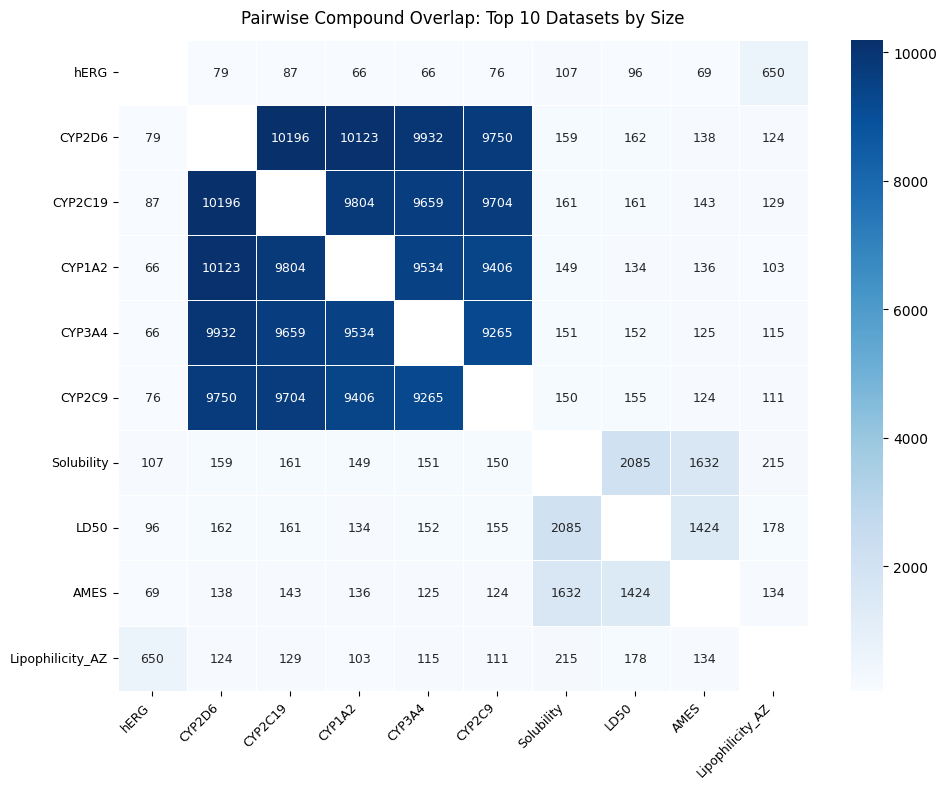

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

all_datasets_combined = {**adme_datasets, **tox_datasets}
top10 = sorted(all_datasets_combined.items(), key=lambda x: len(x[1]), reverse=True)[:10]
top10_names = [name for name, _ in top10]
top10_sizes = [len(s) for _, s in top10]

print('Top 10 datasets by size:')
for name, size in zip(top10_names, top10_sizes):
    print(f'{name}: {size}')

n = len(top10_names)
matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        if i == j:
            matrix[i][j] = np.nan
        else:
            s1 = all_datasets_combined[top10_names[i]]
            s2 = all_datasets_combined[top10_names[j]]
            matrix[i][j] = len(s1.intersection(s2))

short_names = [name.replace('_Veith', '').replace('_Zhu', '').replace('_Karim', '')
               .replace('_AstraZeneca', '_AZ').replace('_AqSolDB', '')
               .replace('_Lagunin', '').replace('CarbonMangels', 'CM')
               for name in top10_names]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(matrix, annot=True, fmt='.0f', cmap='Blues',
            xticklabels=short_names, yticklabels=short_names,
            ax=ax, linewidths=0.5, annot_kws={'size': 9})

ax.set_title('Pairwise Compound Overlap: Top 10 Datasets by Size', pad=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('top10_overlap_heatmap.png', dpi=150)
plt.show()

In [23]:
import pandas as pd
from tdc.single_pred import ADME
from tdc.multi_pred import DDI

# Load all CYP-Veith datasets
cyp_names = [
    'CYP1A2_Veith',
    'CYP2C9_Veith',
    'CYP2C19_Veith',
    'CYP2D6_Veith',
    'CYP3A4_Veith',
]

cyp_smiles = set()
cyp_records = []

for name in cyp_names:
    data = ADME(name=name).get_data()
    for smi in data['Drug'].dropna():
        cyp_smiles.add(smi)
        cyp_records.append({'isoform': name, 'smiles': smi})

cyp_df = pd.DataFrame(cyp_records)
print(f"Total unique CYP-Veith SMILES: {len(cyp_smiles)}")

# Load all TDC DDI datasets
ddi_names = ['DrugBank', 'TWOSIDES']
ddi_smiles = {}

for name in ddi_names:
    try:
        data = DDI(name=name).get_data()
        s1 = set(data['Drug1'].dropna()) if 'Drug1' in data.columns else set()
        s2 = set(data['Drug2'].dropna()) if 'Drug2' in data.columns else set()
        ddi_smiles[name] = s1 | s2
        print(f"{name}: {len(ddi_smiles[name])} unique SMILES")
    except Exception as e:
        print(f"{name} failed: {e}")

# Overall overlap
print("\nOverlap with CYP-Veith:")
for name, smiles_set in ddi_smiles.items():
    overlap = cyp_smiles & smiles_set
    print(f"  {name}: {len(overlap)} drugs in common")

# Per-isoform breakdown
print("\nPer-isoform breakdown:")
for name, smiles_set in ddi_smiles.items():
    print(f"\n  {name}:")
    for iso in cyp_names:
        iso_smiles = set(cyp_df[cyp_df['isoform'] == iso]['smiles'])
        overlap = iso_smiles & smiles_set
        print(f"    {iso}: {len(overlap)} / {len(iso_smiles)} ({100*len(overlap)/len(iso_smiles):.1f}%)")

Downloading...
100%|██████████| 760k/760k [00:00<00:00, 1.83MiB/s]
Loading...
Done!
Downloading...
100%|██████████| 740k/740k [00:00<00:00, 1.39MiB/s]
Loading...
Done!
Downloading...
100%|██████████| 771k/771k [00:00<00:00, 1.60MiB/s]
Loading...
Done!
Downloading...
100%|██████████| 800k/800k [00:00<00:00, 1.49MiB/s]
Loading...
Done!
Downloading...
100%|██████████| 746k/746k [00:00<00:00, 2.03MiB/s]
Loading...
Done!
Downloading...


Total unique CYP-Veith SMILES: 16366


100%|██████████| 44.4M/44.4M [00:03<00:00, 12.4MiB/s]
Loading...
Done!
Downloading...


DrugBank: 1706 unique SMILES


100%|██████████| 677M/677M [01:25<00:00, 7.96MiB/s] 
Loading...
Done!


TWOSIDES: 645 unique SMILES

Overlap with CYP-Veith:
  DrugBank: 9 drugs in common
  TWOSIDES: 1 drugs in common

Per-isoform breakdown:

  DrugBank:
    CYP1A2_Veith: 7 / 12579 (0.1%)
    CYP2C9_Veith: 7 / 12092 (0.1%)
    CYP2C19_Veith: 8 / 12665 (0.1%)
    CYP2D6_Veith: 7 / 13130 (0.1%)
    CYP3A4_Veith: 7 / 12328 (0.1%)

  TWOSIDES:
    CYP1A2_Veith: 1 / 12579 (0.0%)
    CYP2C9_Veith: 1 / 12092 (0.0%)
    CYP2C19_Veith: 1 / 12665 (0.0%)
    CYP2D6_Veith: 1 / 13130 (0.0%)
    CYP3A4_Veith: 1 / 12328 (0.0%)


In [24]:
from rdkit import Chem

def canonicalise(smiles_set):
    canonical = set()
    for smi in smiles_set:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            canonical.add(Chem.MolToSmiles(mol))
    return canonical

cyp_smiles_canon = canonicalise(cyp_smiles)

for name, smiles_set in ddi_smiles.items():
    ddi_smiles[name] = canonicalise(smiles_set)

# Then rerun the overlap computation with the canonical sets
print("\nOverlap after canonicalisation:")
for name, smiles_set in ddi_smiles.items():
    overlap = cyp_smiles_canon & smiles_set
    print(f"  {name}: {len(overlap)} drugs in common")

# Per-isoform
print("\nPer-isoform breakdown:")
for name, smiles_set in ddi_smiles.items():
    print(f"\n  {name}:")
    for iso in cyp_names:
        iso_smiles = canonicalise(set(cyp_df[cyp_df['isoform'] == iso]['smiles']))
        overlap = iso_smiles & smiles_set
        print(f"    {iso}: {len(overlap)} / {len(iso_smiles)} ({100*len(overlap)/len(iso_smiles):.1f}%)")

[11:21:54] SMILES Parse Error: syntax error while parsing: OC1=CC=CC(=C1)C-1=C2\CCC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC(O)=CC=C1)C1=CC(O)=CC=C1)\C1=CC(O)=CC=C1
[11:21:54] SMILES Parse Error: Failed parsing SMILES 'OC1=CC=CC(=C1)C-1=C2\CCC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC(O)=CC=C1)C1=CC(O)=CC=C1)\C1=CC(O)=CC=C1' for input: 'OC1=CC=CC(=C1)C-1=C2\CCC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC(O)=CC=C1)C1=CC(O)=CC=C1)\C1=CC(O)=CC=C1'



Overlap after canonicalisation:
  DrugBank: 246 drugs in common
  TWOSIDES: 91 drugs in common

Per-isoform breakdown:

  DrugBank:
    CYP1A2_Veith: 156 / 12579 (1.2%)
    CYP2C9_Veith: 172 / 12092 (1.4%)
    CYP2C19_Veith: 187 / 12665 (1.5%)
    CYP2D6_Veith: 180 / 13130 (1.4%)
    CYP3A4_Veith: 166 / 12328 (1.3%)

  TWOSIDES:
    CYP1A2_Veith: 55 / 12579 (0.4%)
    CYP2C9_Veith: 57 / 12092 (0.5%)
    CYP2C19_Veith: 63 / 12665 (0.5%)
    CYP2D6_Veith: 68 / 13130 (0.5%)
    CYP3A4_Veith: 52 / 12328 (0.4%)


In [2]:
from tdc.single_pred import ADME

data = ADME(name='CYP2D6_Veith')
df = data.get_data()
smiles_list = df['Drug'].tolist()

from rdkit.Chem import Descriptors
from rdkit import Chem

# check first 20 smiles against common drugs
for i, smi in enumerate(smiles_list[:20]):
    mol = Chem.MolFromSmiles(smi)
    if mol:
        mw = Descriptors.MolWt(mol)
        print(f"{i}: MW={mw:.1f} | {smi[:60]}")

Found local copy...
Loading...
Done!


0: MW=362.5 | CCN1C(=O)/C(=C2\SC(=S)N(CCCOC)C2=O)c2ccccc21
1: MW=355.4 | CC(=O)N(c1ccc2oc(=O)sc2c1)S(=O)(=O)c1cccs1
2: MW=421.5 | COc1ccccc1C(c1nnnn1C(C)(C)C)N1CCN(Cc2ccncc2)CC1
3: MW=380.4 | CC(=O)Nc1cccc(NC(=O)C2CCCN2C(=O)Nc2ccccc2C)c1
4: MW=495.6 | CCC(c1nnnn1CC1CCCO1)N(CCN1CCOCC1)Cc1cc2cc(C)ccc2[nH]c1=O
5: MW=514.3 | Br.N=c1n(CCN2CCOCC2)c2ccccc2n1CC(=O)c1ccc(Cl)c(Cl)c1
6: MW=362.4 | CCC(C)(C)NC(=O)c1ccc2c(c1)N(CC(=O)OC)C(=O)C(C)(C)O2
7: MW=180.2 | CCc1cc2c(=O)[nH]cnc2s1
8: MW=384.5 | CCN(CC)C(=O)CSc1nnc(-c2cc3ccccc3cc2O)n1CC
9: MW=400.5 | CCOc1cc(NC(=O)C2CCCCC2)c(OCC)cc1NC(=O)c1ccco1
10: MW=230.7 | Cl.N/C(=N\O)C1COc2ccccc2O1
11: MW=314.4 | COc1cccc2c(=O)c(C(=O)NCc3cccs3)c[nH]c12
12: MW=292.4 | CCc1nnc(SCc2ccc(OC(C)C)cc2)n1N
13: MW=389.5 | Cc1ccc2c(c1)nnn2C1CCN(CC(=O)N2c3ccccc3CC2C)CC1
14: MW=368.4 | O=C(CSc1nnc2c(n1)[nH]c1ccc(F)cc12)OCc1ccccc1
15: MW=306.4 | CCOC(=O)CSC1=C(C#N)C(C)C2=C(CCCC2=O)N1
16: MW=366.4 | Cc1ccc2cc(C)c3nnc(SCC(=O)NCc4ccco4)n3c2c1
17: MW=395.5 | Cc1ccc(-n2c(SC

In [3]:
aspirin = 'CC(=O)Oc1ccccc1C(=O)O'
print(aspirin in smiles_list)

False


In [4]:
ibuprofen = 'CC(C)Cc1ccc(cc1)C(C)C(=O)O'
print(ibuprofen in smiles_list)

False


In [7]:
cyp_drugs = {
    'Ketoconazole': 'O=C(CN1CCN(CC1)c1ccc(Cl)cc1Cl)c1ccc(OC[C@@H]2CO[C@](Cn3cncn3)(c3ccc(Cl)cc3Cl)O2)cc1',
    'Erythromycin': 'CC[C@@H]1OC(=O)[C@H](C)[C@@H](O[C@@H]2C[C@@](C)(OC)[C@@H](O)[C@H](C)O2)[C@H](C)[C@@H](O[C@@H]2O[C@H](C)C[C@@H](N(C)C)[C@H]2O)[C@](C)(O)C[C@@H](C)C(=O)[C@H](C)[C@@H](O)[C@]1(C)O',
    'Fluconazole': 'OC(Cn1cncn1)(Cn1cncn1)c1ccc(F)cc1F',
    'Quinidine': 'COc1ccc2nccc([C@@H](O)[C@H]3C[C@@H]4CC[N@@]3C[C@@H]4C=C)c2c1',
    'Verapamil': 'COc1ccc(CCN(C)CCCC(C#N)(c2ccc(OC)c(OC)c2)C(C)C)cc1OC',
    'Nifedipine': 'COC(=O)C1=C(C)NC(C)=C(C(=O)OC)C1c1ccccc1[N+](=O)[O-]',
    'Cimetidine': 'CN(/C=N/C#N)NCCSc1nc[nH]c1C',
    'Rifampicin': 'COc1c(C)c2c(NC(=O)/C(=C/[C@@H]3CC(=O)[C@H](O)/C(=C/[C@@H](OC(C)=O)[C@@H](C)OC3=O)C)C)ccc2c(OC)c1OC',
}

for name, smi in cyp_drugs.items():
    print(f"{name}: {smi in smiles_list}")

Ketoconazole: False
Erythromycin: False
Fluconazole: False
Quinidine: False
Verapamil: False
Nifedipine: False
Cimetidine: False
Rifampicin: False


Found local copy...
Loading...
Done!
Downloading...
100%|██████████| 746k/746k [00:00<00:00, 1.96MiB/s]
Loading...
Done!


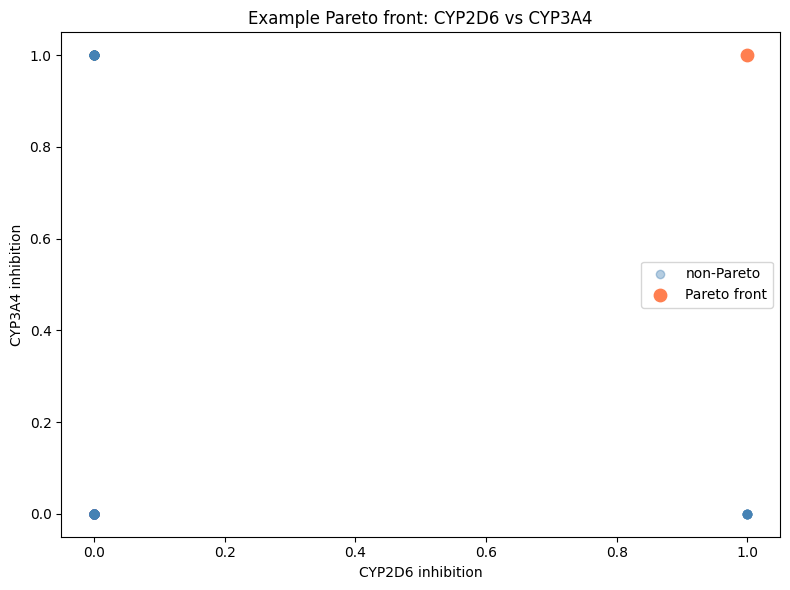

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from tdc.single_pred import ADME

# load two CYP datasets
data1 = ADME(name='CYP2D6_Veith').get_data()[['Drug', 'Y']].rename(columns={'Y': 'CYP2D6'})
data2 = ADME(name='CYP3A4_Veith').get_data()[['Drug', 'Y']].rename(columns={'Y': 'CYP3A4'})

merged = data1.merge(data2, on='Drug').dropna()
sample = merged.sample(200, random_state=42)

# find pareto front (maximising both)
def is_pareto(costs):
    is_efficient = np.ones(costs.shape[0], dtype=bool)
    for i, c in enumerate(costs):
        if is_efficient[i]:
            is_efficient[is_efficient] = np.any(costs[is_efficient] > c, axis=1)
            is_efficient[i] = True
    return is_efficient

costs = sample[['CYP2D6', 'CYP3A4']].values
pareto_mask = is_pareto(costs)

plt.figure(figsize=(8, 6))
plt.scatter(sample['CYP2D6'][~pareto_mask], sample['CYP3A4'][~pareto_mask],
            alpha=0.4, label='non-Pareto', color='steelblue')
plt.scatter(sample['CYP2D6'][pareto_mask], sample['CYP3A4'][pareto_mask],
            color='coral', zorder=5, label='Pareto front', s=80)
plt.xlabel('CYP2D6 inhibition')
plt.ylabel('CYP3A4 inhibition')
plt.title('Example Pareto front: CYP2D6 vs CYP3A4')
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
pareto_molecules = sample[pareto_mask][['Drug', 'CYP2D6', 'CYP3A4']]
print(pareto_molecules.to_string())

                                                           Drug  CYP2D6  CYP3A4
2554  CCC(Sc1nc2cc3c(cc2c(=O)n1Cc1ccco1)OCO3)C(=O)Nc1cccc(OC)c1       1       1
